Loading building 23 ...
25.0
True
Saved to visualizations/building_23_domain_and_interior.png


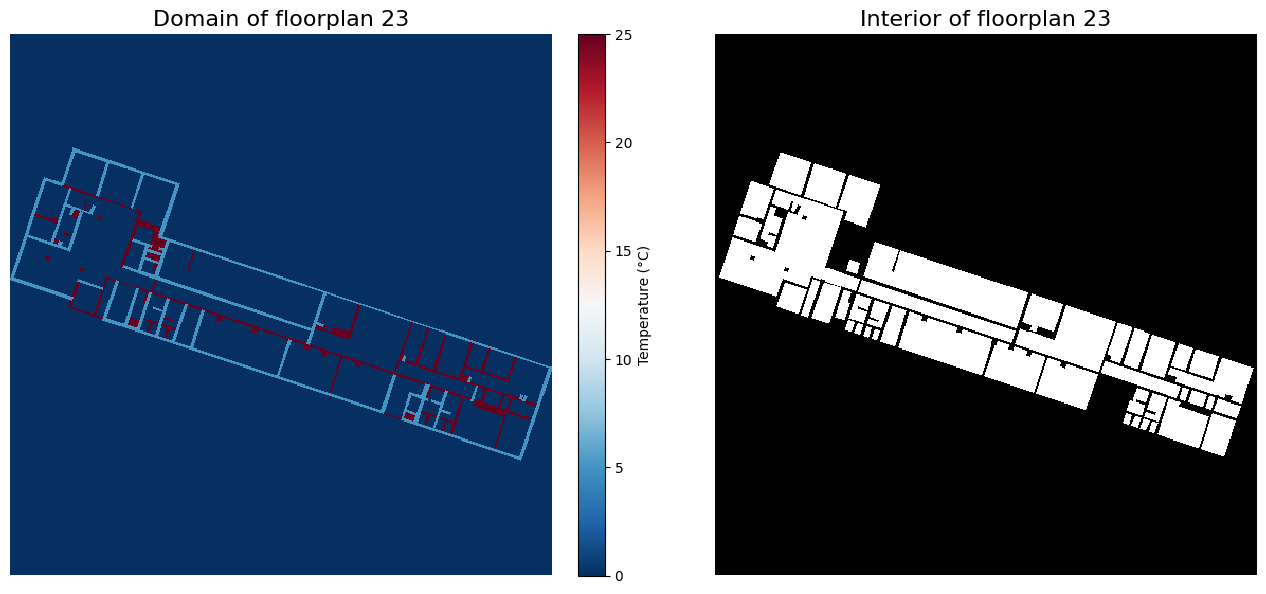

In [15]:
import matplotlib.pyplot as plt
from os.path import join
import sys
import numpy as np
import matplotlib.pyplot as plt

LOAD_DIR = 'modified_swiss_dwellings/'
MAX_ITER = 20_000
ABS_TOL  = 1e-4

def load_data(load_dir, bid):
    SIZE = 512
    u = np.zeros((SIZE + 2, SIZE + 2))
    u[1:-1, 1:-1] = np.load(join(load_dir, f"{bid}_domain.npy"))
    interior_mask = np.load(join(load_dir, f"{bid}_interior.npy"))
    return u, interior_mask

def visualize(bid):
    print(f"Loading building {bid} ...")
    u_before, mask = load_data(LOAD_DIR, bid)


    domain_before = u_before[1:-1, 1:-1]
    wall_mask    = (~mask) & (domain_before != 0)
    interior = mask.astype(int)


    plot_dmoain = domain_before
    plot_interior  = mask
    plot_interior = mask*25

    vmin = 0
    vmax = np.nanmax(plot_dmoain)
    print(np.max(domain_before))
    print(np.max(mask))

    fig, ax = plt.subplots(1, 2, figsize=(14, 6))
    cmap = plt.cm.RdBu_r.copy()
    cmap.set_bad(color='lightgrey')

    im = ax[0].imshow(plot_dmoain, origin='upper', cmap=cmap,
                       vmin=vmin, vmax=vmax, interpolation='nearest')
    ax[0].set_title(f"Domain of floorplan {bid}", fontsize=16)
    ax[0].axis('off')
    fig.colorbar(im, ax=ax[0], fraction=0.046, pad=0.04, label='Temperature (°C)')


    im = ax[1].imshow(plot_interior, origin='upper', cmap='gray',
                       vmin=vmin, vmax=vmax, interpolation='nearest')
    ax[1].set_title(f"Interior of floorplan {bid}", fontsize=16)
    ax[1].axis('off')
    # for ax, data, title in zip(
    #     axes,
    #     [plot_dmoain, plot_interior],
    #     [f"Domain of floorplan {bid}",
    #      f"Interior of floorplan {bid}"],
    # ):
    #     im = ax.imshow(data, origin='upper', cmap=cmap,
    #                    vmin=vmin, vmax=vmax, interpolation='nearest')
    #     ax.set_title(title, fontsize=12)
    #     ax.axis('off')
        
    #     fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Temperature (°C)')

    plt.tight_layout()
    out = f"visualizations/building_{bid}_domain_and_interior.png"
    plt.savefig(out, dpi=150, bbox_inches='tight')
    print(f"Saved to {out}")
    plt.show()


visualize('23')

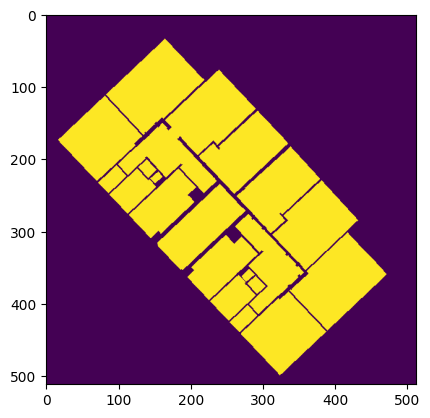

In [9]:
interior_mask = np.load(join(LOAD_DIR, f"{10075}_interior.npy"))
interior_mask.astype(int)

plt.imshow(interior_mask)

In [ ]:
def estimate_parallel(initial_time, faster_time, cores):
    S = initial_time/faster_time
    F = (1-S)/(-S+S/cores)
    max_S = 1/(1-F)

    print(f'S= {S} \nF={F} \nS_max={max_S}')
    return S,F,max_S

In [44]:
# opgave 5 static scheduling
estimate_parallel(180.05, 28.50, 32)

S= 6.317543859649123 
F=0.8688625919323486 
S_max=7.625589179588774


In [45]:
# opgave 5 dynamic scheduling:
estimate_parallel(180.05, 29.38, 32)

S= 6.128318584070797 
F=0.8638173983929196 
S_max=7.343081922353347
